In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")
print("Please verify that '/content/drive/MyDrive/titanic_clean.parquet' exists.")

Mounted at /content/drive
Google Drive mounted successfully!
Please verify that '/content/drive/MyDrive/titanic_clean.parquet' exists.


Datos cargados: (714, 14)
Distribución de clases:
Survived
0    424
1    290
Name: count, dtype: int64
Porcentaje de supervivencia: 40.62%
Train: 571 registros
Test: 143 registros

Logistic Regression:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85        85
           1       0.78      0.79      0.79        58

    accuracy                           0.83       143
   macro avg       0.82      0.82      0.82       143
weighted avg       0.83      0.83      0.83       143

AUC: 0.865

Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        85
           1       0.71      0.71      0.71        58

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143

AUC: 0.826

Gradient Boosting:
              precision    recall  f1-score   support

           0       0.80      0.

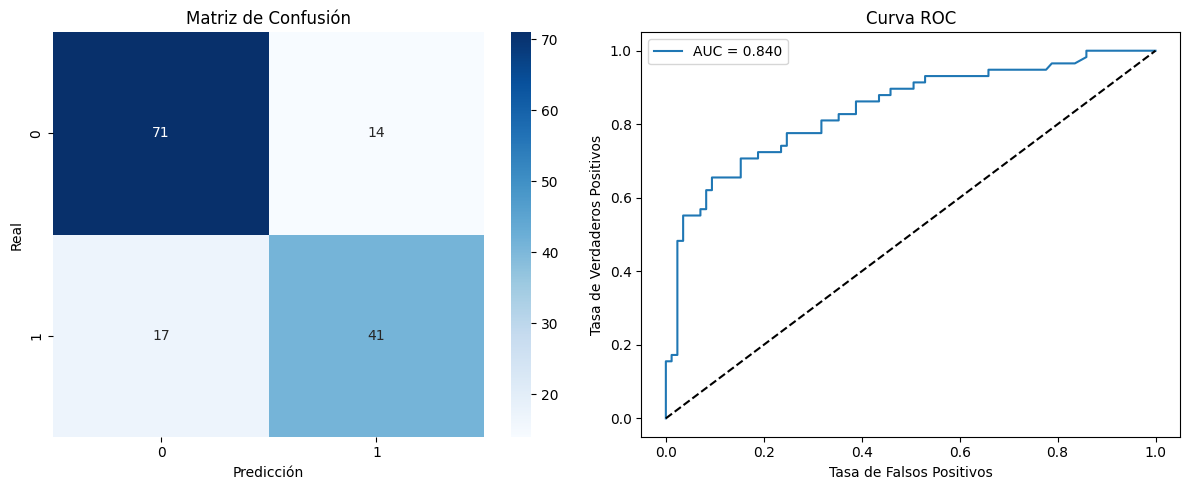


Feature Importance:
         feature  importance
1       SexIndex    0.273675
5           Fare    0.228177
2            Age    0.199204
0         Pclass    0.112790
8     FamilySize    0.049399
7  AgeGroupIndex    0.038792
6  EmbarkedIndex    0.029499
3          SibSp    0.029207
4          Parch    0.026478
9        IsAlone    0.012778
Modelo y scaler guardados exitosamente

Top 10 pasajeros con mayor riesgo:
     Pclass  SexIndex  Age    Fare  Survival_Probability  Risk_Score
61        3       0.0   22   9.000                   0.0         1.0
106       2       0.0   25  13.000                   0.0         1.0
181       3       0.0   22   9.350                   0.0         1.0
231       3       0.0   22   7.896                   0.0         1.0
276       2       0.0   25  13.000                   0.0         1.0
282       3       0.0   23   9.225                   0.0         1.0
291       3       0.0   35   7.050                   0.0         1.0
372       3       0.0   38   7.05

In [5]:
# Celda 1: Importar librerías
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                           roc_auc_score, roc_curve, accuracy_score,
                           precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Celda 2: Cargar datos procesados
spark = SparkSession.builder.appName("TitanicML").getOrCreate()
sdf = spark.read.parquet("/content/drive/MyDrive/titanic_clean.parquet")

# Convertir a pandas para usar sklearn
df = sdf.toPandas()
print("Datos cargados:", df.shape)
df.head()

# Celda 3: Preparar features y target
# Seleccionar columnas para el modelo
feature_cols = ['Pclass', 'SexIndex', 'Age', 'SibSp', 'Parch', 'Fare',
                'EmbarkedIndex', 'AgeGroupIndex', 'FamilySize', 'IsAlone']

X = df[feature_cols]
y = df['Survived']  # 1 = sobrevivió, 0 = no sobrevivió

# Verificar balance de clases
print(f"Distribución de clases:\n{y.value_counts()}")
print(f"Porcentaje de supervivencia: {y.mean()*100:.2f}%")

# Celda 4: Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} registros")
print(f"Test: {len(X_test)} registros")

# Celda 5: Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Celda 6: Entrenar modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred_proba)
    }
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))
    print(f"AUC: {results[name]['auc']:.3f}")

# Celda 7: Resultados comparativos
results_df = pd.DataFrame(results).T
print("\nResultados comparativos:")
print(results_df.round(3))

# Celda 8: Mejor modelo - Random Forest con optimización
# Grid Search para Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor AUC: {grid_search.best_score_:.3f}")

# Celda 9: Evaluar modelo final
best_rf = grid_search.best_estimator_
y_pred_final = best_rf.predict(X_test_scaled)
y_pred_proba_final = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\nModelo final - Random Forest:")
print(classification_report(y_test, y_pred_final))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_final):.3f}")

# Celda 10: Matriz de confusión y curva ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Matriz de Confusión')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
ax2.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba_final):.3f}')
ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_title('Curva ROC')
ax2.set_xlabel('Tasa de Falsos Positivos')
ax2.set_ylabel('Tasa de Verdaderos Positivos')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/titanic_model_results.png')
plt.show()

# Celda 11: Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Celda 12: Guardar modelo
joblib.dump(best_rf, '/content/drive/MyDrive/titanic_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/titanic_scaler.pkl')
print("Modelo y scaler guardados exitosamente")

# Celda 13: Top 10 pasajeros con mayor riesgo
# Ahora predecimos para todos los datos
X_scaled = scaler.transform(X) # Escalar el conjunto de datos completo X
all_probs = best_rf.predict_proba(X_scaled)[:, 1]
df['Survival_Probability'] = all_probs
df['Risk_Score'] = 1 - all_probs  # Riesgo = 1 - probabilidad de supervivencia

top_risk = df.nlargest(10, 'Risk_Score')[['Pclass', 'SexIndex', 'Age', 'Fare', 'Survival_Probability', 'Risk_Score']]
print("\nTop 10 pasajeros con mayor riesgo:")
print(top_risk.round(3))